In [1]:
!pip install -q tf-explain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, Input, Activation
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

from tf_explain.core.integrated_gradients import IntegratedGradients

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

## Part A — CIFAR-10 Image Classifier

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Training Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4731s 28us/step
Training Shape: (50000, 32, 32, 3)
Test Shape: (10000, 32, 32, 3)


**Note on the model architecture:** classic **CAM** (Class Activation Mapping, Zhou et al.) is only
mathematically valid for networks that end in `Global Average Pooling -> single Dense(num_classes) layer`,
because CAM reconstructs the class heatmap directly from the weights of that final Dense layer. The original
notebook used `Flatten -> Dense(128) -> Dropout -> Dense(10)`, so there was no way to compute a *true*
class-discriminative CAM from it (only a generic, class-agnostic average of the feature maps, which is what
the old Cell 12 was actually doing). The architecture below fixes this by ending in GAP + a single linear
Dense layer, which supports CAM, Grad-CAM, and Integrated Gradients all at once.

In [4]:
inputs = Input(shape=(32, 32, 3))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)

# LAST CONV LAYER (used by both Grad-CAM and CAM)
x = Conv2D(128, (3, 3), activation='relu', padding='same', name="last_conv")(x)

x = GlobalAveragePooling2D()(x)

# Linear (no activation) Dense so we can access raw logits for Grad-CAM/CAM,
# and a separate softmax Activation layer for training/prediction.
logits = Dense(10, use_bias=False, name="predictions")(x)
outputs = Activation('softmax', name="softmax_out")(logits)

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_out (Activation)        │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,528 (369.25 KB)

 Trainable params: 94,528 (369.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    x_train,
    y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=30,
    batch_size=64
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3258 - loss: 1.7889 - val_accuracy: 0.4268 - val_loss: 1.5762
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4443 - loss: 1.5205 - val_accuracy: 0.4873 - val_loss: 1.4072
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5052 - loss: 1.3756 - val_accuracy: 0.5257 - val_loss: 1.3040
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5436 - loss: 1.2790 - val_accuracy: 0.5578 - val_loss: 1.2278
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5712 - loss: 1.2089 - val_accuracy: 0.5802 - val_loss: 1.1698
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5920 - loss: 1.1527 - val_accuracy: 0.5982 - val_loss: 1.1227
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6095 - loss: 1.1045 - val_accuracy: 0.6155 - val_loss: 1.0780
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6242 - loss: 1.0625 - val_accuracy: 0

In [7]:
loss, acc = model.evaluate(x_test, y_test_cat)
print("\nTest Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7315 - loss: 0.7938

Test Accuracy: 0.7315000295639038


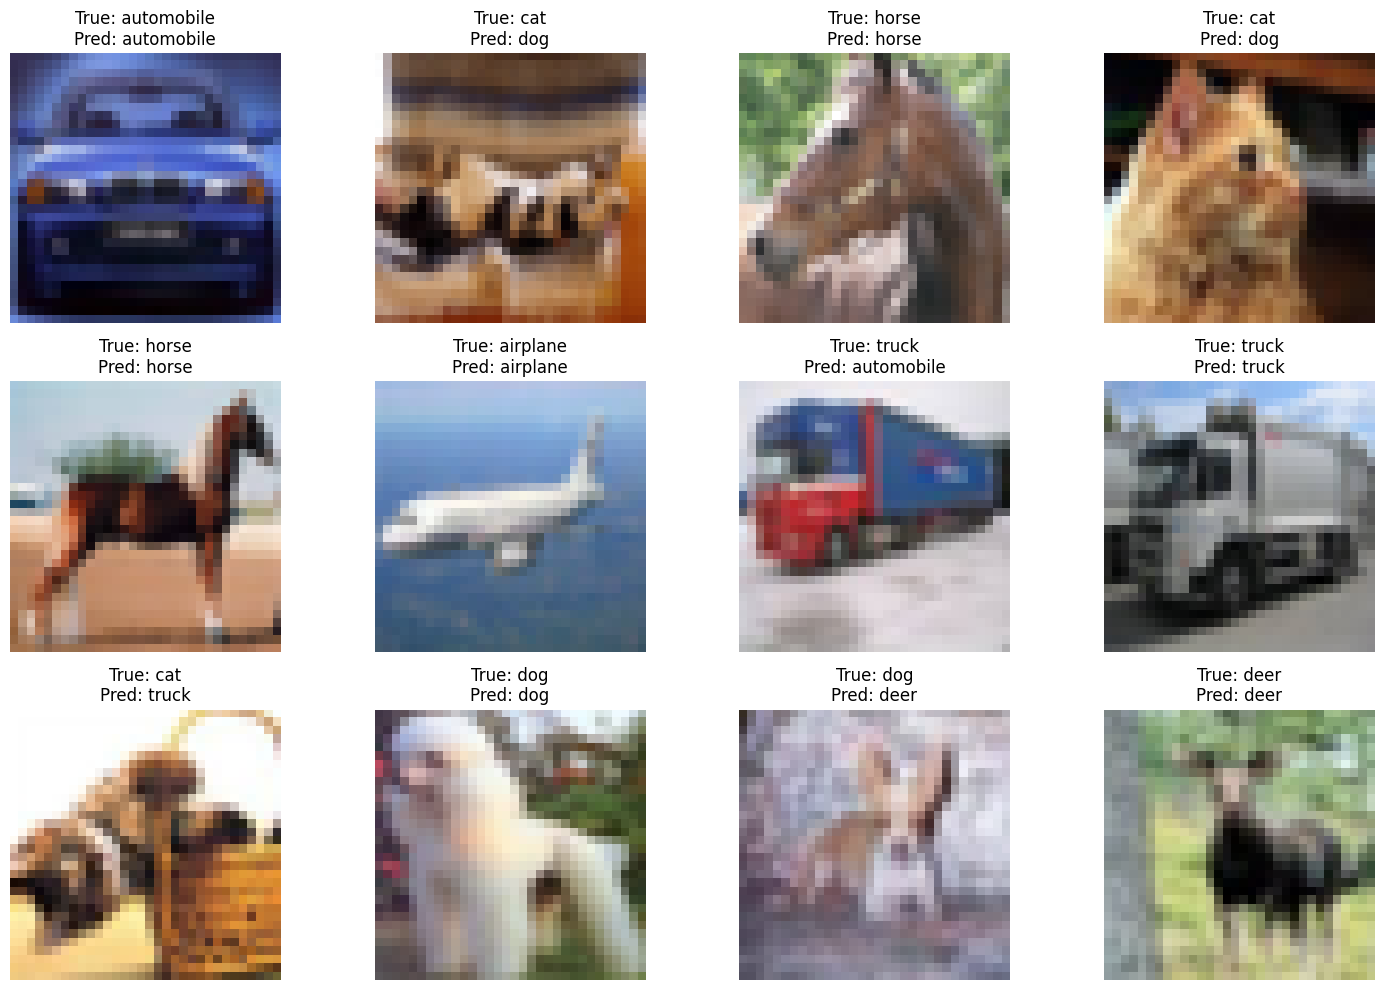

In [8]:
num_images = 12
random_indices = random.sample(range(len(x_test)), num_images)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    img = x_test[idx]
    true_label = y_test[idx][0]
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_class = np.argmax(pred)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_class]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Pick one image to explain.** (Previously the code silently relied on whatever the `for` loop
happened to leave in `sample_image`/`sample_label` from the visualization grid above — it worked, but it
was fragile and made the notebook confusing to re-run. Here the explained image is chosen explicitly.)

In [9]:
explain_idx = random_indices[0]
sample_image = x_test[explain_idx]
sample_label = y_test[explain_idx][0]
img_array = np.expand_dims(sample_image, axis=0)

pred_probs = model.predict(img_array, verbose=0)
predicted_class = np.argmax(pred_probs[0])

print(f"Explaining test image #{explain_idx}")
print(f"True label:      {class_names[sample_label]}")
print(f"Predicted label: {class_names[predicted_class]} (confidence {pred_probs[0][predicted_class]:.3f})")

Explaining test image #4506
True label:      automobile
Predicted label: automobile (confidence 0.933)


### Grad-CAM

In [10]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_layer_name, pred_index=None):
    """Grad-CAM computed from RAW LOGITS (pred_layer_name), not post-softmax probabilities.
    Using logits avoids the gradient-saturation issue that softmax can introduce."""
    grad_model = Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.get_layer(pred_layer_name).output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, logits = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(logits[0])
        class_channel = logits[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


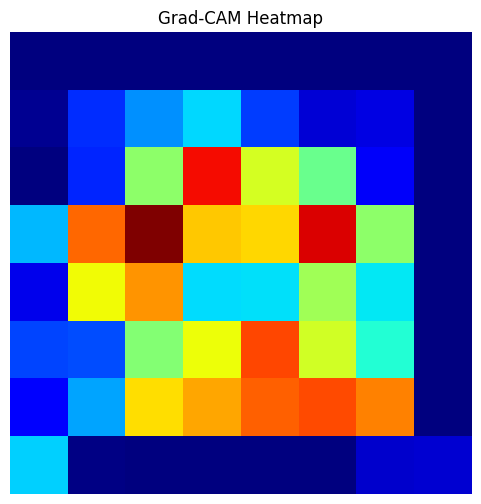

In [11]:
heatmap = make_gradcam_heatmap(
    img_array, model, "last_conv", "predictions", pred_index=predicted_class
)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

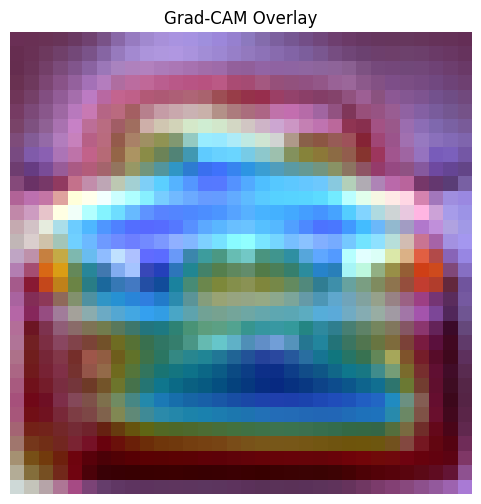

In [12]:
def overlay_heatmap(heatmap, original_img_float01, alpha=0.4):
    """original_img_float01: HxWx3 image scaled to [0,1]. Returns a clipped uint8 overlay."""
    h, w = original_img_float01.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET).astype("float32")

    base = original_img_float01 * 255.0
    superimposed = heatmap_color * alpha + base
    # IMPORTANT FIX: clip before casting to uint8, otherwise values above 255
    # wrap around instead of saturating and the overlay gets corrupted colors.
    superimposed = np.clip(superimposed, 0, 255).astype("uint8")
    return superimposed

gradcam_overlay = overlay_heatmap(heatmap, sample_image)

plt.figure(figsize=(6, 6))
plt.imshow(gradcam_overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.show()

### CAM (Class Activation Mapping)

True CAM (Zhou et al., 2016) reconstructs the heatmap directly from the final Dense layer's weights for the
predicted class — that's what makes it *class-discriminative* (a cat image and a dog image get different
maps). This only works because the model above ends in `GlobalAveragePooling2D -> Dense(10, use_bias=False)`.

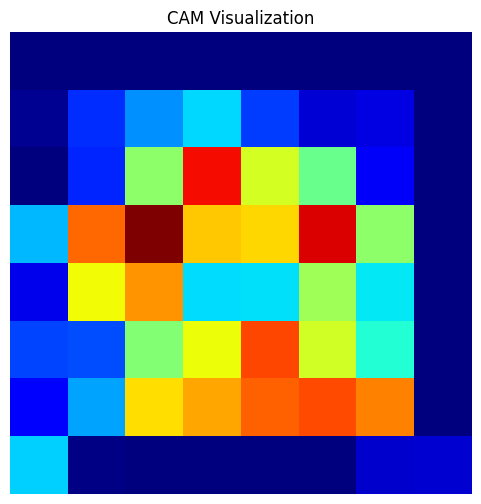

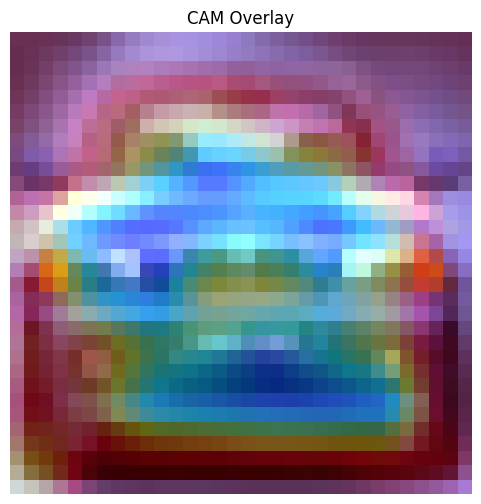

In [13]:
def make_cam_heatmap(img_array, model, last_conv_layer_name, dense_layer_name, pred_index=None):
    feature_map_model = Model(model.inputs, model.get_layer(last_conv_layer_name).output)
    feature_maps = feature_map_model.predict(img_array, verbose=0)[0]  # (h, w, channels)

    dense_weights = model.get_layer(dense_layer_name).get_weights()[0]  # (channels, num_classes)

    if pred_index is None:
        preds = model.predict(img_array, verbose=0)
        pred_index = np.argmax(preds[0])

    class_weights = dense_weights[:, pred_index]  # (channels,)

    h, w, channels = feature_maps.shape
    cam = np.dot(feature_maps.reshape(h * w, channels), class_weights).reshape(h, w)

    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)
    return cam

cam = make_cam_heatmap(img_array, model, "last_conv", "predictions", pred_index=predicted_class)

plt.figure(figsize=(6, 6))
plt.imshow(cam, cmap='jet')
plt.title("CAM Visualization")
plt.axis("off")
plt.show()

cam_overlay = overlay_heatmap(cam, sample_image)
plt.figure(figsize=(6, 6))
plt.imshow(cam_overlay)
plt.title("CAM Overlay")
plt.axis("off")
plt.show()

### Integrated Gradients

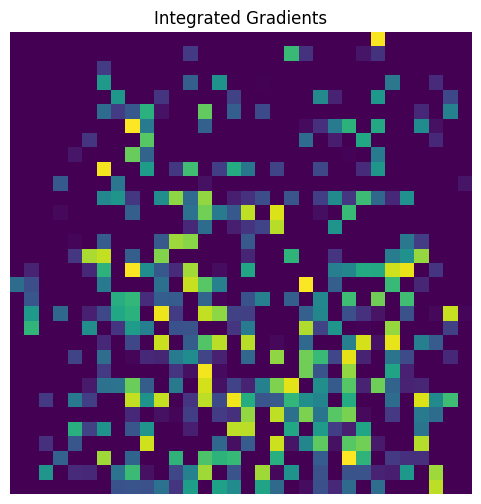

In [14]:
ig = IntegratedGradients()

ig_grid = ig.explain(
    validation_data=(img_array, None),
    model=model,
    class_index=int(predicted_class)
)

plt.figure(figsize=(6, 6))
plt.imshow(ig_grid)
plt.title("Integrated Gradients")
plt.axis("off")
plt.show()

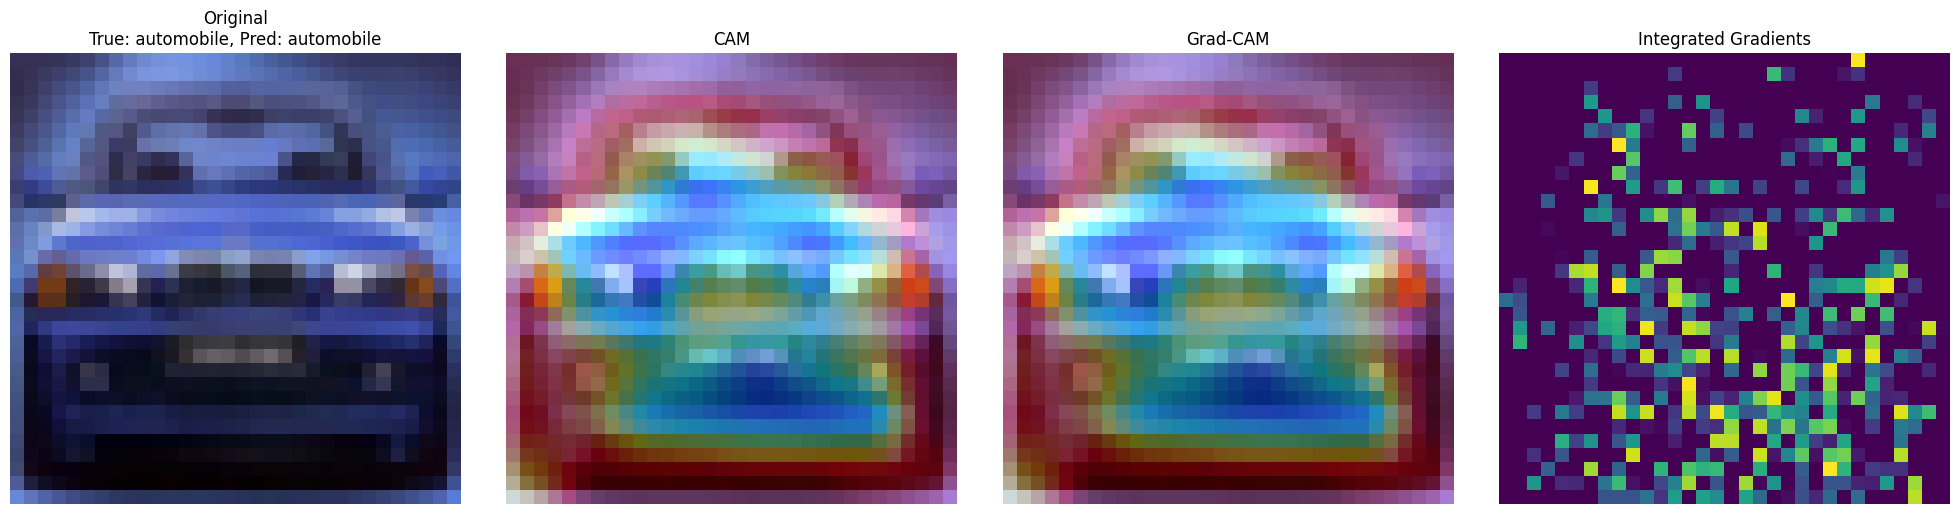

In [15]:
# Side-by-side comparison: CAM vs Grad-CAM vs Integrated Gradients
# (same image, same predicted class, so the three explanations are directly comparable)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(sample_image)
axes[0].set_title(f"Original\nTrue: {class_names[sample_label]}, Pred: {class_names[predicted_class]}")
axes[0].axis("off")

axes[1].imshow(cam_overlay)
axes[1].set_title("CAM")
axes[1].axis("off")

axes[2].imshow(gradcam_overlay)
axes[2].set_title("Grad-CAM")
axes[2].axis("off")

axes[3].imshow(ig_grid)
axes[3].set_title("Integrated Gradients")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### Analysis — comparing CAM, Grad-CAM, and Integrated Gradients (CIFAR-10)

**Localization granularity.** CAM and Grad-CAM both produce coarse, blob-like heatmaps because they
are built from the last convolutional feature map (here 4x4 before upsampling to 32x32) - they show
*which region* of the image drove the prediction, not fine object boundaries. Integrated Gradients
operates in pixel space, so it produces a much finer-grained, noisier map that can highlight edges and
individual pixels rather than a smooth region.

**Agreement between CAM and Grad-CAM.** Because this model ends in `GAP -> Dense(use_bias=False)`,
CAM and Grad-CAM are mathematically near-identical here - Grad-CAM's gradient-based weighting reduces
to (approximately) the same class weights that CAM reads directly from the Dense layer. Any visible
difference between the two heatmaps above is mostly numerical (ReLU thresholding, normalization),
not a difference in what they're measuring. This is expected only because of the GAP+linear-Dense
architecture - for a model with more Dense layers after GAP, CAM would not be computable this way and
the two methods would diverge more.

**Why Integrated Gradients still adds value.** Even though it looks noisier, IG attributes importance
to individual input pixels by integrating gradients along a path from a baseline (black) image to the
real image, which satisfies axioms (sensitivity, implementation invariance) that Grad-CAM does not
guarantee. In practice, CAM/Grad-CAM are better for a quick, human-readable "where is the model
looking," while IG is better when precise, pixel-level attribution matters (e.g. debugging why two
visually similar images get different predictions).

**Class-discriminativeness.** All three methods here are computed with respect to the *predicted*
class (`predicted_class`), so all three are class-discriminative by construction - re-running them
with a different `pred_index` would produce a different heatmap emphasizing the regions relevant to
that other class, which is the key property CAM-family methods rely on and a plain saliency map does
not have.

## Part B — Face Classifier (images captured on a mobile phone)

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Fix:** the original notebook never mounted Google Drive before reading from
`/content/drive/MyDrive/dataset/person`, which would raise a `FileNotFoundError` on a fresh runtime.
The loader below also skips non-folder entries (e.g. `.ipynb_checkpoints`) and unreadable images,
which the original silently assumed would never happen.

In [17]:
IMG_SIZE = 128
dataset_path = "/content/drive/MyDrive/dataset/person"

data = []
labels = []

people = sorted([
    p for p in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, p))
])

for label_index, person_name in enumerate(people):
    person_folder = os.path.join(dataset_path, person_name)

    for img_name in os.listdir(person_folder):
        img_path = os.path.join(person_folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            print(f"Skipping unreadable file: {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        data.append(img)
        labels.append(label_index)

data = np.array(data)
labels = np.array(labels)
labels_cat = to_categorical(labels, num_classes=len(people))

print("Face Dataset Shape:", data.shape)
print("People (classes):", people)

# Train/test split (stratified where possible) so the face classifier can be evaluated
# on held-out images instead of only ever being judged on data it was trained on.
# With this few images per class, some classes may have too few samples to stratify;
# fall back to a plain random split in that case.
try:
    data_train, data_test, labels_train, labels_test = train_test_split(
        data, labels, test_size=0.2, random_state=42, stratify=labels
    )
except ValueError as e:
    print(f"Stratified split failed ({e}); falling back to a non-stratified split.")
    data_train, data_test, labels_train, labels_test = train_test_split(
        data, labels, test_size=0.2, random_state=42
    )

labels_cat_train = to_categorical(labels_train, num_classes=len(people))
labels_cat_test = to_categorical(labels_test, num_classes=len(people))

print(f"Face dataset: {len(data)} images total, {len(people)} classes "
      f"({len(data) / len(people):.1f} images/class on average)")
print("Train shape:", data_train.shape, "| Test shape:", data_test.shape)

Face Dataset Shape: (35, 128, 128, 3)
People (classes): ['al-amin', 'reeky', 'saba', 'sania', 'shawda', 'shawon', 'sifat']
Face dataset: 35 images total, 7 classes (5.0 images/class on average)
Train shape: (28, 128, 128, 3) | Test shape: (7, 128, 128, 3)


In [18]:
face_inputs = Input(shape=(128, 128, 3))

f = Conv2D(32, (3, 3), activation='relu', padding='same')(face_inputs)
f = MaxPooling2D((2, 2))(f)

f = Conv2D(64, (3, 3), activation='relu', padding='same')(f)
f = MaxPooling2D((2, 2))(f)

f = Conv2D(128, (3, 3), activation='relu', padding='same', name="face_last_conv")(f)

f = GlobalAveragePooling2D()(f)

face_logits = Dense(len(people), use_bias=False, name="face_predictions")(f)
face_outputs = Activation('softmax', name="face_softmax_out")(face_logits)

face_model = Model(face_inputs, face_outputs)

face_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

face_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ face_last_conv (Conv2D)         │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ face_predictions (Dense)        │ (None, 7)              │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ face_softmax_out (Activation)   │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,144 (367.75 KB)

 Trainable params: 94,144 (367.75 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
face_history = face_model.fit(
    data_train,
    labels_cat_train,
    validation_data=(data_test, labels_cat_test),
    epochs=30,
    batch_size=8
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 884ms/step - accuracy: 0.1071 - loss: 1.9840 - val_accuracy: 0.1429 - val_loss: 1.9446
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1786 - loss: 1.9394 - val_accuracy: 0.1429 - val_loss: 1.9372
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1786 - loss: 1.9336 - val_accuracy: 0.1429 - val_loss: 1.9317
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1429 - loss: 1.9300 - val_accuracy: 0.1429 - val_loss: 1.9230
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1786 - loss: 1.9226 - val_accuracy: 0.2857 - val_loss: 1.9058
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2857 - loss: 1.9074 - val_accuracy: 0.2857 - val_loss: 1.8775
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2857 - loss: 1.8813 - val_accuracy: 0.2857 - val_loss: 1.8368
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2857 - loss: 1.8439 - val_accuracy: 0.2857 - val_loss: 1.7795

In [20]:
face_test_loss, face_test_acc = face_model.evaluate(data_test, labels_cat_test, verbose=0)
print(f"Face classifier — held-out test accuracy: {face_test_acc:.3f} (loss: {face_test_loss:.3f})")
print(f"Face classifier — final training accuracy: {face_history.history['accuracy'][-1]:.3f}")

gap = face_history.history['accuracy'][-1] - face_test_acc
if gap > 0.15:
    print(f"Train/test accuracy gap is {gap:.2f} — likely overfitting, "
          f"expected given only {len(data)} images across {len(people)} classes.")

Face classifier — held-out test accuracy: 0.857 (loss: 0.464)
Face classifier — final training accuracy: 0.893


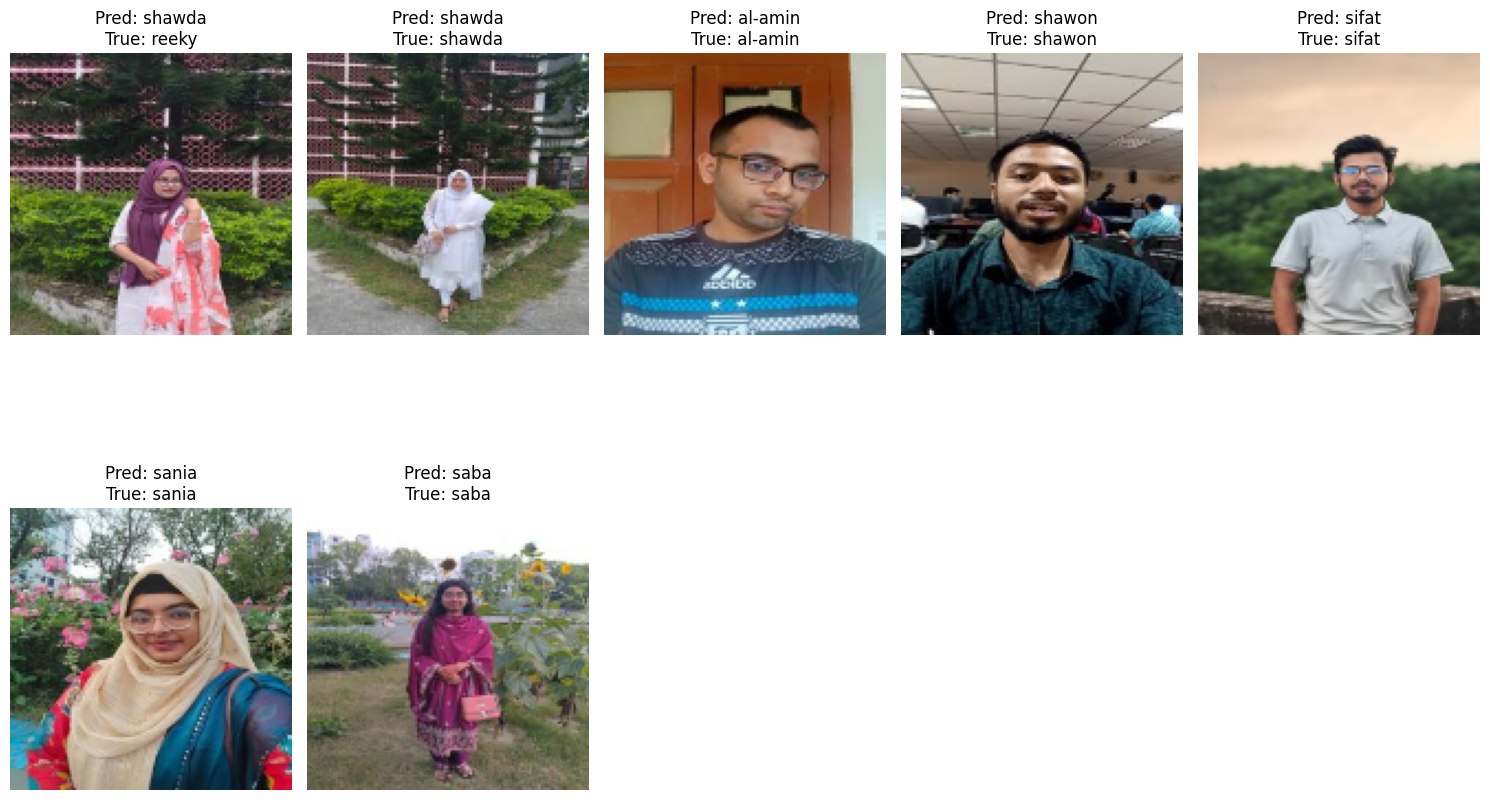

In [21]:
num_tests = min(10, len(data_test))
random_indices_face = random.sample(range(len(data_test)), num_tests)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices_face):
    test_face_img = data_test[idx]
    pred = face_model.predict(np.expand_dims(test_face_img, axis=0), verbose=0)
    pred_class = np.argmax(pred)
    true_class = labels_test[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(test_face_img)
    plt.title(f"Pred: {people[pred_class]}\nTrue: {people[true_class]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
face_explain_idx = random_indices_face[-1]
test_face = data_test[face_explain_idx]
face_img_array = np.expand_dims(test_face, axis=0)

face_pred_probs = face_model.predict(face_img_array, verbose=0)
face_pred_class = np.argmax(face_pred_probs[0])

print(f"Explaining face image #{face_explain_idx} (from held-out test set)")
print(f"True label:      {people[labels_test[face_explain_idx]]}")
print(f"Predicted label: {people[face_pred_class]} (confidence {face_pred_probs[0][face_pred_class]:.3f})")

Explaining face image #2 (from held-out test set)
True label:      saba
Predicted label: saba (confidence 0.737)


### Face — Grad-CAM

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_9']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


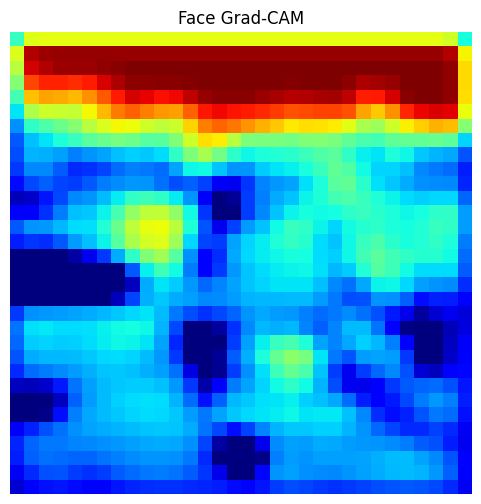

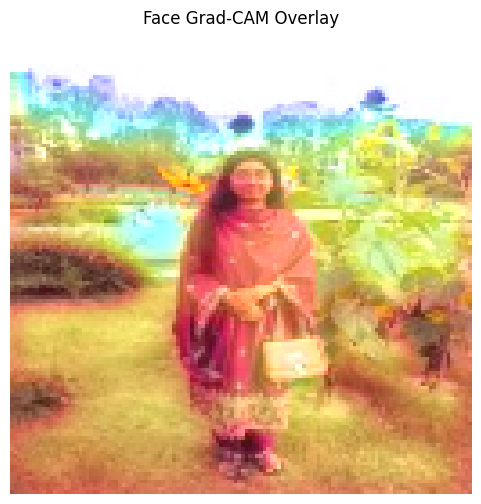

In [23]:
face_heatmap = make_gradcam_heatmap(
    face_img_array, face_model, "face_last_conv", "face_predictions", pred_index=face_pred_class
)

plt.figure(figsize=(6, 6))
plt.imshow(face_heatmap, cmap='jet')
plt.title("Face Grad-CAM")
plt.axis("off")
plt.show()

face_gradcam_overlay = overlay_heatmap(face_heatmap, test_face)
plt.figure(figsize=(6, 6))
plt.imshow(face_gradcam_overlay)
plt.title("Face Grad-CAM Overlay")
plt.axis("off")
plt.show()

### Face — CAM

The original notebook never applied CAM to the face classifier at all (only Grad-CAM and Integrated
Gradients) — added here for completeness, mirroring Part A.

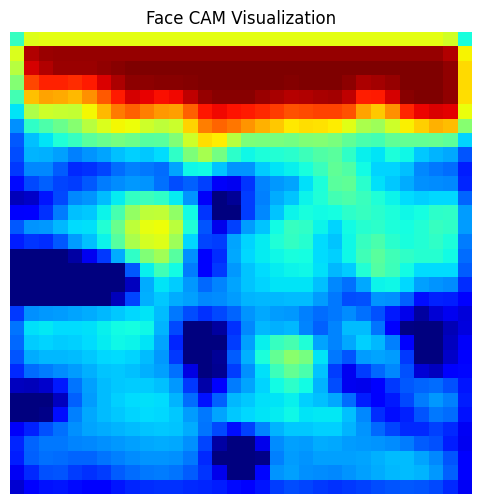

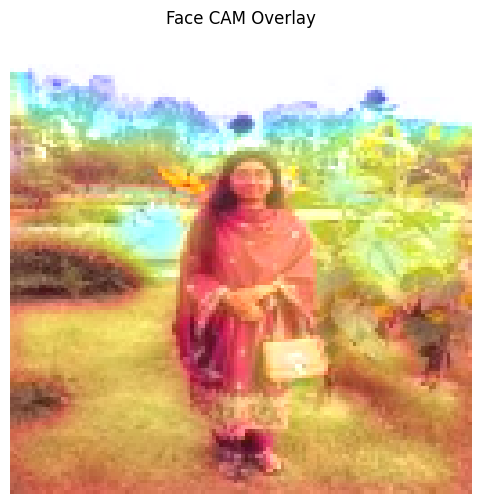

In [24]:
face_cam = make_cam_heatmap(
    face_img_array, face_model, "face_last_conv", "face_predictions", pred_index=face_pred_class
)

plt.figure(figsize=(6, 6))
plt.imshow(face_cam, cmap='jet')
plt.title("Face CAM Visualization")
plt.axis("off")
plt.show()

face_cam_overlay = overlay_heatmap(face_cam, test_face)
plt.figure(figsize=(6, 6))
plt.imshow(face_cam_overlay)
plt.title("Face CAM Overlay")
plt.axis("off")
plt.show()

### Face — Integrated Gradients

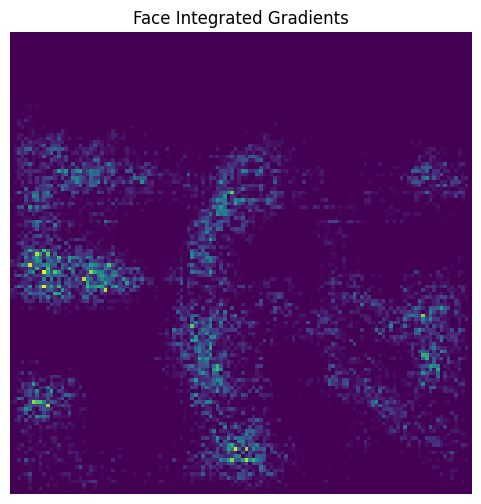

In [25]:
face_ig = IntegratedGradients()

face_ig_grid = face_ig.explain(
    validation_data=(face_img_array, None),
    model=face_model,
    class_index=int(face_pred_class)
)

plt.figure(figsize=(6, 6))
plt.imshow(face_ig_grid)
plt.title("Face Integrated Gradients")
plt.axis("off")
plt.show()

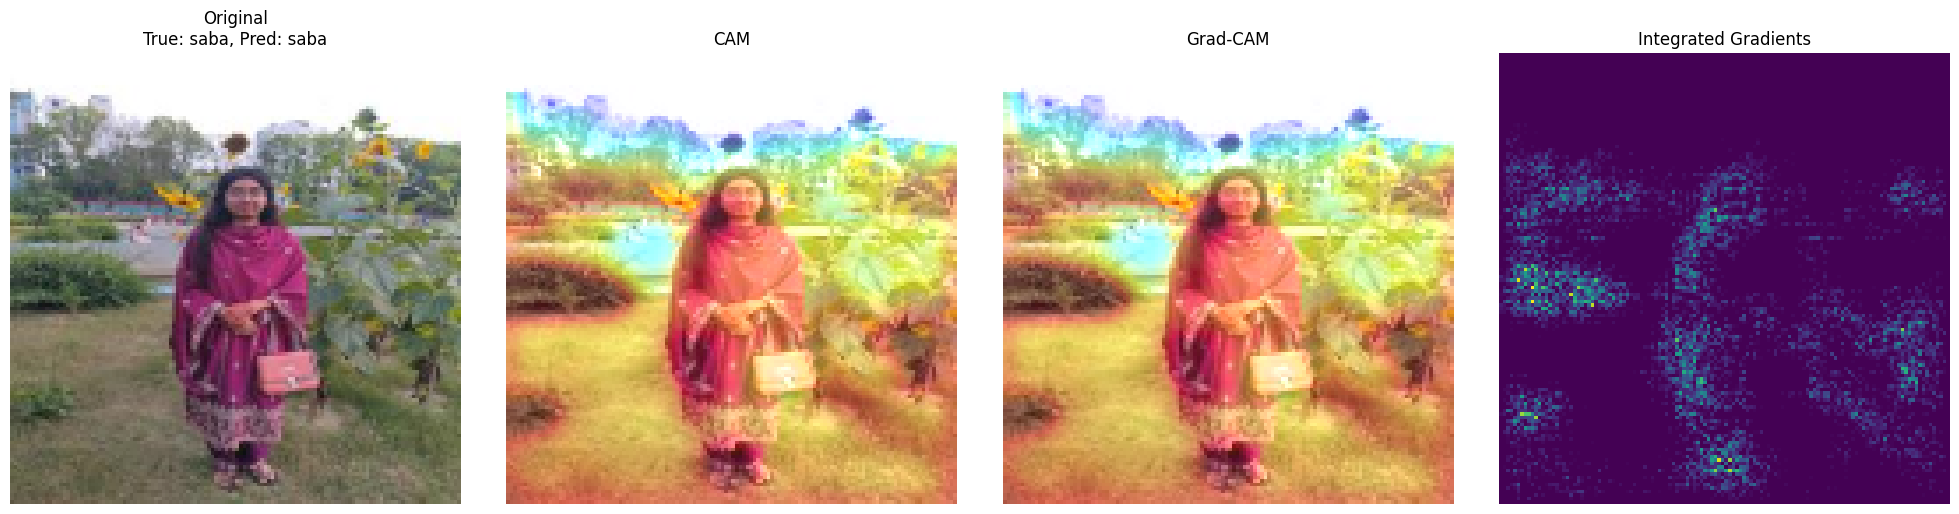

In [26]:
# Side-by-side comparison: CAM vs Grad-CAM vs Integrated Gradients (face classifier)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(test_face)
axes[0].set_title(f"Original\nTrue: {people[labels_test[face_explain_idx]]}, Pred: {people[face_pred_class]}")
axes[0].axis("off")

axes[1].imshow(face_cam_overlay)
axes[1].set_title("CAM")
axes[1].axis("off")

axes[2].imshow(face_gradcam_overlay)
axes[2].set_title("Grad-CAM")
axes[2].axis("off")

axes[3].imshow(face_ig_grid)
axes[3].set_title("Integrated Gradients")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### Analysis — face classifier explainability, and why the dataset size matters

**Dataset size caveat.** This classifier was trained on roughly 35 images spread across 7 people
(about 5 images per person), with an 80/20 held-out split for evaluation (see the train/test cell
above and the reported test accuracy). That is a very small dataset for a CNN trained from scratch,
so before trusting the heatmaps below as "what the model learned about faces," it's worth checking
the train-vs-test accuracy gap reported earlier: a large gap means the model has likely memorized
these specific 35 photos (backgrounds, lighting, camera angle) rather than learning general facial
features, and the CAM/Grad-CAM/IG maps below would then be explaining that memorization rather than
genuine face-identity reasoning.

**Comparing the three methods on faces.** The same pattern as Part A holds: CAM and Grad-CAM localize
to a coarse region (ideally the face/eyes/nose area for a well-trained model, but on a small dataset
they may instead highlight background or hair if that's what's spuriously correlated with identity in
so few training images), while Integrated Gradients gives a finer per-pixel attribution map. If CAM/
Grad-CAM highlight non-face regions (background, clothing) rather than facial features, that's a
concrete, visual sign of the small-dataset overfitting risk noted above - it means the model found a
shortcut correlated with identity in this tiny dataset rather than a genuine facial signature.

**Takeaway.** For a production face-verification system, the fix is more images per person (or
transfer learning from a face-pretrained backbone) rather than a bigger custom CNN - explainability
tools like these are exactly how you'd catch a shortcut-learning problem like this before deployment,
which is the practical value of applying CAM/Grad-CAM/IG here beyond just visualizing predictions.